In [80]:
from datetime import datetime, timezone, timedelta
import bottleneck
from datetime import datetime, timezone
import matplotlib.pyplot as plt
import os
import numpy as np
import multiprocessing
import pandas as pd
import xarray as xr
import requests
from requests.compat import urljoin
import warnings
import fsspec
from typing import Union

In [32]:
cuti = pd.read_csv('C:/Users/annar/OneDrive/Documents/GitHub/python3-crlx/examples/Annas scripts/CUTI_daily (2).csv')
cuti_dates = pd.DataFrame({'year': cuti['year'],
                   'month': cuti['month'],
                   'day': cuti['day']})
dates = pd.to_datetime(cuti_dates)

In [33]:
cuti = cuti.assign(cuti_dates = dates)

In [70]:
cuti_ooi = cuti[(cuti['year'] > 2023) & (cuti_ooi['month'] > 6)]

In [71]:
cuti_ooi

,year,month,day,31N,32N,33N,34N,35N,36N,37N,...,39N,40N,41N,42N,43N,44N,45N,46N,47N,cuti_dates
13331,2024,7,1,0.643,0.702,0.408,0.899,1.159,1.431,1.347,...,2.319,1.533,1.026,0.808,0.270,-0.206,0.024,0.115,0.037,2024-07-01
13332,2024,7,2,0.520,0.404,0.202,0.812,0.932,1.159,1.238,...,2.547,2.669,2.394,1.767,1.235,0.611,0.482,0.080,0.357,2024-07-02
13333,2024,7,3,0.717,0.465,0.086,0.254,0.092,-0.029,0.405,...,2.751,3.501,4.371,3.775,3.324,1.421,1.063,0.658,0.801,2024-07-03
13334,2024,7,4,0.444,0.550,0.157,0.219,0.194,-0.413,0.025,...,0.997,2.322,2.754,3.644,2.122,1.766,1.204,0.927,0.504,2024-07-04
13335,2024,7,5,0.596,0.481,0.408,0.681,0.575,0.199,0.160,...,-0.344,0.241,-0.050,0.915,1.225,1.398,1.005,0.859,0.395,2024-07-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13393,2024,9,1,0.684,0.630,0.530,0.857,0.905,0.597,0.616,...,-0.254,0.070,-0.081,-0.264,0.178,-0.005,0.072,0.206,0.190,2024-09-01
13394,2024,9,2,0.587,0.605,0.456,1.012,1.401,1.071,0.765,...,0.035,-0.002,-0.017,-0.209,-0.303,-0.139,-0.112,-0.144,0.240,2024-09-02
13395,2024,9,3,0.300,0.349,0.297,0.845,1.092,1.105,1.024,...,0.394,0.499,-0.009,0.255,0.063,0.091,-0.109,-0.032,0.130,2024-09-03
13396,2024,9,4,0.295,0.341,0.355,0.763,0.720,0.318,0.819,...,0.676,1.136,0.942,1.522,1.357,0.679,0.432,0.380,0.309,2024-09-04


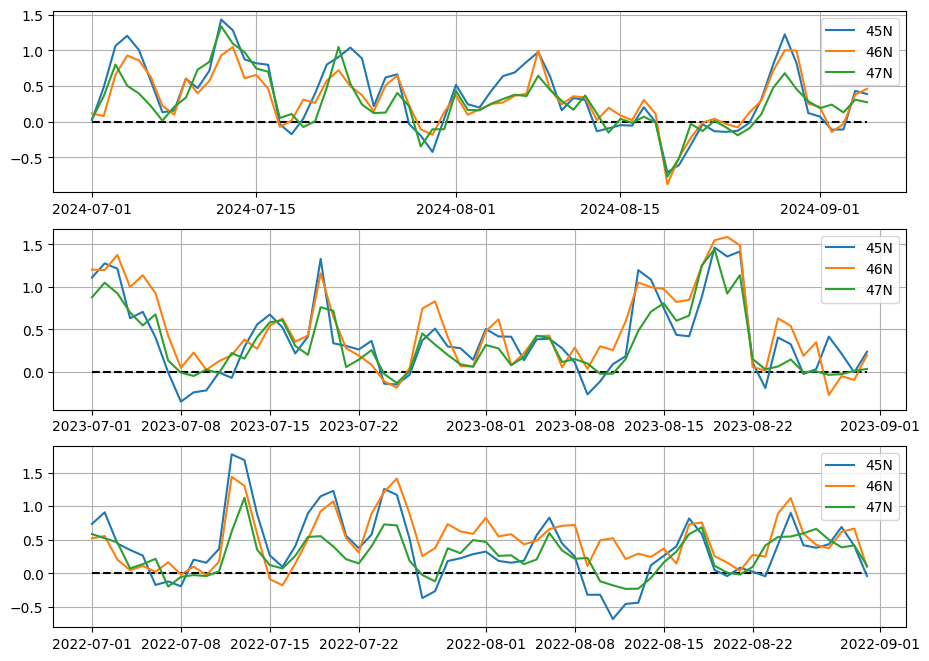

In [85]:
fig,ax = plt.subplots(3,1, figsize=(11,8))

ax[0].plot([min(cuti_ooi.cuti_dates),max(cuti_ooi.cuti_dates)],[0,0],color='black',linestyle = '--')
ax[0].plot(cuti_ooi.cuti_dates,cuti_ooi['45N'],label='45N')
ax[0].plot(cuti_ooi.cuti_dates,cuti_ooi['46N'],label='46N')
ax[0].plot(cuti_ooi.cuti_dates,cuti_ooi['47N'],label='47N')
ax[0].legend()
ax[0].grid()

cuti_2023 = cuti[(cuti['year'] > 2022) & (cuti['month'] > 6) & (cuti['year'] < 2024) & (cuti['month'] < 9)]

ax[1].plot([min(cuti_2023.cuti_dates),max(cuti_2023.cuti_dates)],[0,0],color='black',linestyle = '--')
ax[1].plot(cuti_2023.cuti_dates,cuti_2023['45N'],label='45N')
ax[1].plot(cuti_2023.cuti_dates,cuti_2023['46N'],label='46N')
ax[1].plot(cuti_2023.cuti_dates,cuti_2023['47N'],label='47N')
ax[1].legend()
ax[1].grid()

cuti_2022 = cuti[(cuti['year'] > 2021) & (cuti['month'] > 6) & (cuti['year'] < 2023) & (cuti['month'] < 9)]

ax[2].plot([min(cuti_2022.cuti_dates),max(cuti_2022.cuti_dates)],[0,0],color='black',linestyle = '--')
ax[2].plot(cuti_2022.cuti_dates,cuti_2022['45N'],label='45N')
ax[2].plot(cuti_2022.cuti_dates,cuti_2022['46N'],label='46N')
ax[2].plot(cuti_2022.cuti_dates,cuti_2022['47N'],label='47N')
ax[2].legend()
ax[2].grid()

In [81]:
def load_files(lookup: str) -> xr.Dataset:
    local = fsspec.filesystem('file')
    files = local.glob(lookup)
    with multiprocessing.Pool() as pool:
        ds_list = pool.map(xr.open_dataset, files)
    try:
        ds = xr.combine_by_coords(ds_list, combine_attrs='drop_conflicts')
    except:
        ds = xr.concat(ds_list, dim='time', combine_attrs='drop_conflicts')
        ds = ds.drop_duplicates(dim='time')
    ds = ds.sortby('time')
    return ds

In [82]:
apollo = load_files('C:/Users/annar/Box/pco2_skq/data/daily/*APOLLO*/*APOLLO*.nc')
apollo = apollo[['air_temperature', 'apollo_sbe45_sea_water_temperature', 'apollo_sbe45_sea_water_practical_salinity',
                 'barometric_pressure', 'fco2', 'pco2', 'sea_surface_temperature', 'sea_water_practical_salinity',
                 'water_vapor_pressure', 'xco2_corr', 'li7815_h2o', 'li7815_xco2']]
apollo = apollo.sel(time=slice(datetime(2024, 8, 14, 12, 0, 0, 0), None))

apollo_air = apollo.sel(sample_source='air')
apollo_air = apollo_air.rolling({'time': 16}, center='True', min_periods=1).median(skipna=True)
apollo_air = apollo_air.resample({'time': '15min'}).mean(skipna=True)

apollo_sea = apollo.sel(sample_source='seawater')
apollo_sea = apollo_sea.rolling({'time': 16}, center='True', min_periods=1).median(skipna=True)
apollo_sea = apollo_sea.resample({'time': '15min'}).mean(skipna=True)

In [83]:
ldeo = load_files('C:/Users/annar/Box/pco2_skq/data/daily/*LDEO*/*LDEO*.nc')
ldeo = ldeo.sel(time=slice(datetime(2024, 8, 14, 12, 0, 0, 0), None))

ldeo_air = ldeo.sel(sample_source='air')
ldeo_air = ldeo_air.rolling({'time': 16}, center='True', min_periods=1).median(skipna=True)
ldeo_air = ldeo_air.resample({'time': '15min'}).mean(skipna=True)

ldeo_sea = ldeo.sel(sample_source='seawater')
ldeo_sea = ldeo_sea.rolling({'time': 16}, center='True', min_periods=1).median(skipna=True)
ldeo_sea = ldeo_sea.resample({'time': '15min'}).mean(skipna=True)

In [84]:
delta_sw_x = ldeo_sea.xco2_corr - apollo_sea.xco2_corr
delta_at_x = ldeo_air.xco2_corr - ldeo_sea.xco2_corr
delta_sw =  ldeo_sea.fco2 - apollo_sea.fco2
delta_at = ldeo_air.fco2 - apollo_air.fco2

In [85]:
ldeo_air_aug = ldeo_air.sel(time = slice(datetime(2024,8,14,12,0,0,0),datetime(2024,8,28,23,59,59,59)))
ldeo_sea_aug = ldeo_sea.sel(time = slice(datetime(2024,8,14,12,0,0,0),datetime(2024,8,28,23,59,59,59)))

ldeo_air_se1 = ldeo_air.sel(time = slice(datetime(2024,9,1,0,0,0,0),datetime(2024,9,12,23,59,59,59)))
ldeo_sea_se1 = ldeo_sea.sel(time = slice(datetime(2024,9,1,0,0,0,0),datetime(2024,9,12,23,59,59,59)))

ldeo_air_se2 = ldeo_air.sel(time = slice(datetime(2024,9,19,0,0,0,0),datetime(2024,9,30,23,59,59,59)))
ldeo_sea_se2 = ldeo_sea.sel(time = slice(datetime(2024,9,19,0,0,0,0),datetime(2024,9,30,23,59,59,59)))

ldeo_air_oct = ldeo_air.sel(time = slice(datetime(2024,10,4,0,0,0,0),None))
ldeo_sea_oct = ldeo_sea.sel(time = slice(datetime(2024,10,4,0,0,0,0),None))

apollo_air_aug = apollo_air.sel(time = slice(datetime(2024,8,14,12,0,0,0),datetime(2024,8,28,23,59,59,59)))
apollo_sea_aug = apollo_sea.sel(time = slice(datetime(2024,8,14,12,0,0,0),datetime(2024,8,28,23,59,59,59)))

apollo_air_se1 = apollo_air.sel(time = slice(datetime(2024,9,1,0,0,0,0),datetime(2024,9,12,23,59,59,59)))
apollo_sea_se1 = apollo_sea.sel(time = slice(datetime(2024,9,1,0,0,0,0),datetime(2024,9,12,23,59,59,59)))

apollo_air_se2 = apollo_air.sel(time = slice(datetime(2024,9,19,0,0,0,0),datetime(2024,9,30,23,59,59,59)))
apollo_sea_se2 = apollo_sea.sel(time = slice(datetime(2024,9,19,0,0,0,0),datetime(2024,9,30,23,59,59,59)))

apollo_air_oct = apollo_air.sel(time = slice(datetime(2024,10,4,0,0,0,0),None))
apollo_sea_oct = apollo_sea.sel(time = slice(datetime(2024,10,4,0,0,0,0),None))

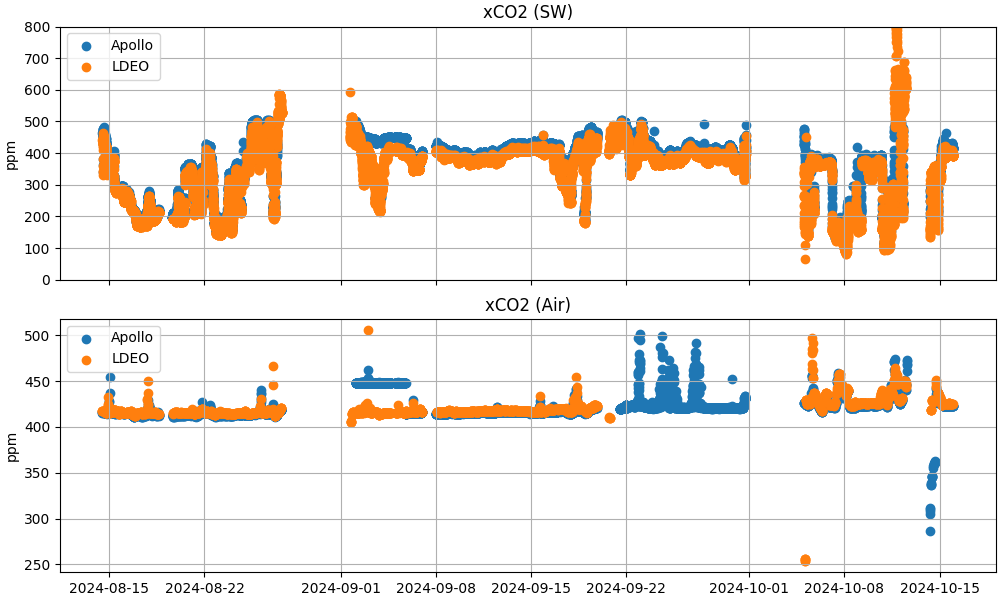

In [25]:
%matplotlib widget

fig, ax = plt.subplots(2,1,figsize = (10,6),sharex = True, constrained_layout = True)
ax[0].scatter(apollo.time.where(apollo.sample_source == 'seawater'), apollo.xco2_corr.where(apollo.sample_source == 'seawater'), label='Apollo')
ax[0].scatter(ldeo.time.where(ldeo.sample_source == 'seawater'), ldeo.xco2_corr.where(ldeo.sample_source == 'seawater'), label='LDEO')
ax[0].set_title('xCO2 (SW)')
ax[0].set_ylabel('ppm')
ax[0].grid()
ax[0].set_ylim(0,800)
ax[0].legend()

ax[1].scatter(apollo.time.where(apollo.sample_source == 'air'), apollo.xco2_corr.where(apollo.sample_source == 'air'), label='Apollo')
ax[1].scatter(ldeo.time.where(ldeo.sample_source == 'air'), ldeo.xco2_corr.where(ldeo.sample_source == 'air'), label='LDEO')
ax[1].set_title('xCO2 (Air)')
ax[1].set_ylabel('ppm')
ax[1].grid()
ax[1].legend()

#fig.savefig("C:/Users/annar/OneDrive/Documents/OSU/Research/RCRV/Apollo/ApolloOnTheSKQ/Figures/full_aug_oct.jpg", dpi=300)

C:\Users\annar\AppData\Local\Temp\ipykernel_41228\3608579821.py:19: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.savefig("C:/Users/annar/OneDrive/Documents/OSU/Research/RCRV/Apollo/ApolloOnTheSKQ/Figures/full_fco2_aug_oct.jpg", dpi=300)
C:\Users\annar\AppData\Local\Temp\ipykernel_41228\3608579821.py:19: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.savefig("C:/Users/annar/OneDrive/Documents/OSU/Research/RCRV/Apollo/ApolloOnTheSKQ/Figures/full_fco2_aug_oct.jpg", dpi=300)
C:\Users\annar\OneDrive\Documents\GitHub\python3-crlx\.venv\lib\site-packages\ipympl\backend_nbagg.py:336: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  self.figure.savefig(buf, format='png', dpi='figure')


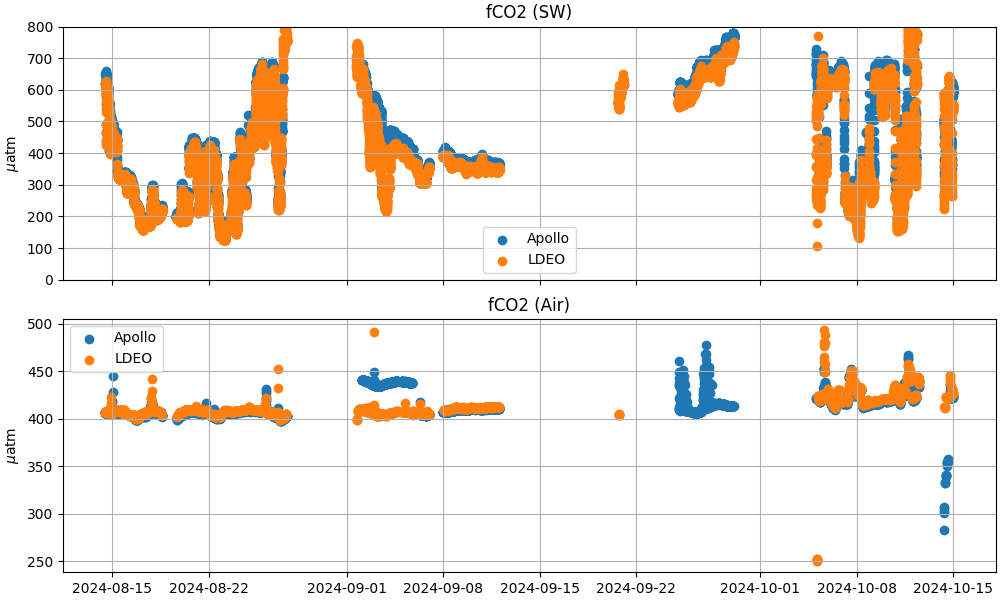

In [16]:
%matplotlib widget

fig, ax = plt.subplots(2,1,figsize = (10,6),sharex = True, constrained_layout = True)
ax[0].scatter(apollo.time.where(apollo.sample_source == 'seawater'), apollo.fco2.where(apollo.sample_source == 'seawater'), label='Apollo')
ax[0].scatter(ldeo.time.where(ldeo.sample_source == 'seawater'), ldeo.fco2.where(ldeo.sample_source == 'seawater'), label='LDEO')
ax[0].set_title('fCO2 (SW)')
ax[0].set_ylabel('$\mu$atm')
ax[0].grid()
ax[0].set_ylim(0,800)
ax[0].legend()

ax[1].scatter(apollo.time.where(apollo.sample_source == 'air'), apollo.fco2.where(apollo.sample_source == 'air'), label='Apollo')
ax[1].scatter(ldeo.time.where(ldeo.sample_source == 'air'), ldeo.fco2.where(ldeo.sample_source == 'air'), label='LDEO')
ax[1].set_title('fCO2 (Air)')
ax[1].set_ylabel('$\mu$atm')
ax[1].grid()
ax[1].legend()

#fig.savefig("C:/Users/annar/OneDrive/Documents/OSU/Research/RCRV/Apollo/ApolloOnTheSKQ/Figures/full_fco2_aug_oct.jpg", dpi=300)

In [86]:
delta_air_aug = ldeo_air_aug.fco2-apollo_air_aug.fco2
delta_air_se1 = ldeo_air_se1.sel(time = slice(datetime(2024,9,6,0,0,0,0),datetime(2024,9,12,0,0,0,0))).fco2-apollo_air_se1.sel(time = slice(datetime(2024,9,6,0,0,0,0),datetime(2024,9,12,0,0,0,0))).fco2
delta_air_se2 = ldeo_air_se2.fco2-apollo_air_se2.fco2
delta_air_oct = ldeo_air_oct.fco2-apollo_air_oct.fco2
delta_sea_aug = ldeo_sea_aug.fco2-apollo_sea_aug.fco2
delta_sea_se1 = ldeo_sea_se1.sel(time = slice(datetime(2024,9,6,0,0,0,0),datetime(2024,9,12,0,0,0,0))).fco2-apollo_sea_se1.sel(time = slice(datetime(2024,9,6,0,0,0,0),datetime(2024,9,12,0,0,0,0))).fco2
delta_sea_se2 = ldeo_sea_se2.fco2-apollo_sea_se2.fco2
delta_sea_oct = ldeo_sea_oct.fco2-apollo_sea_oct.fco2

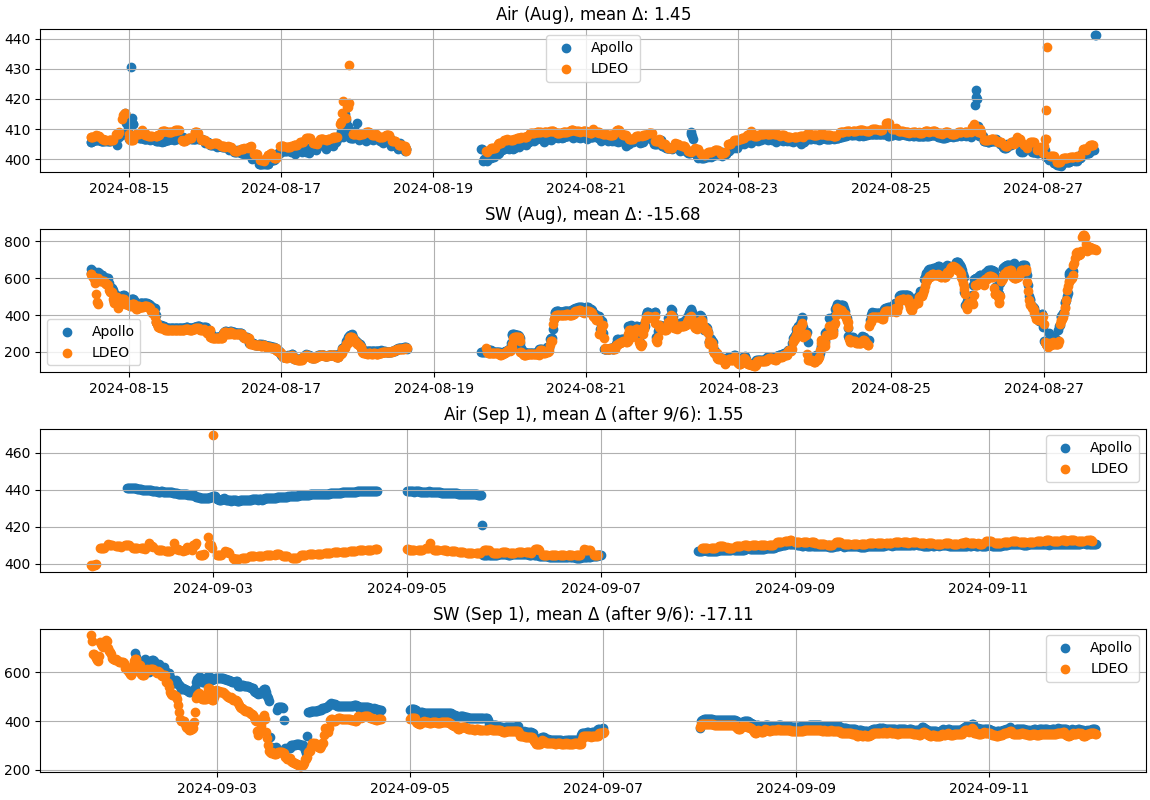

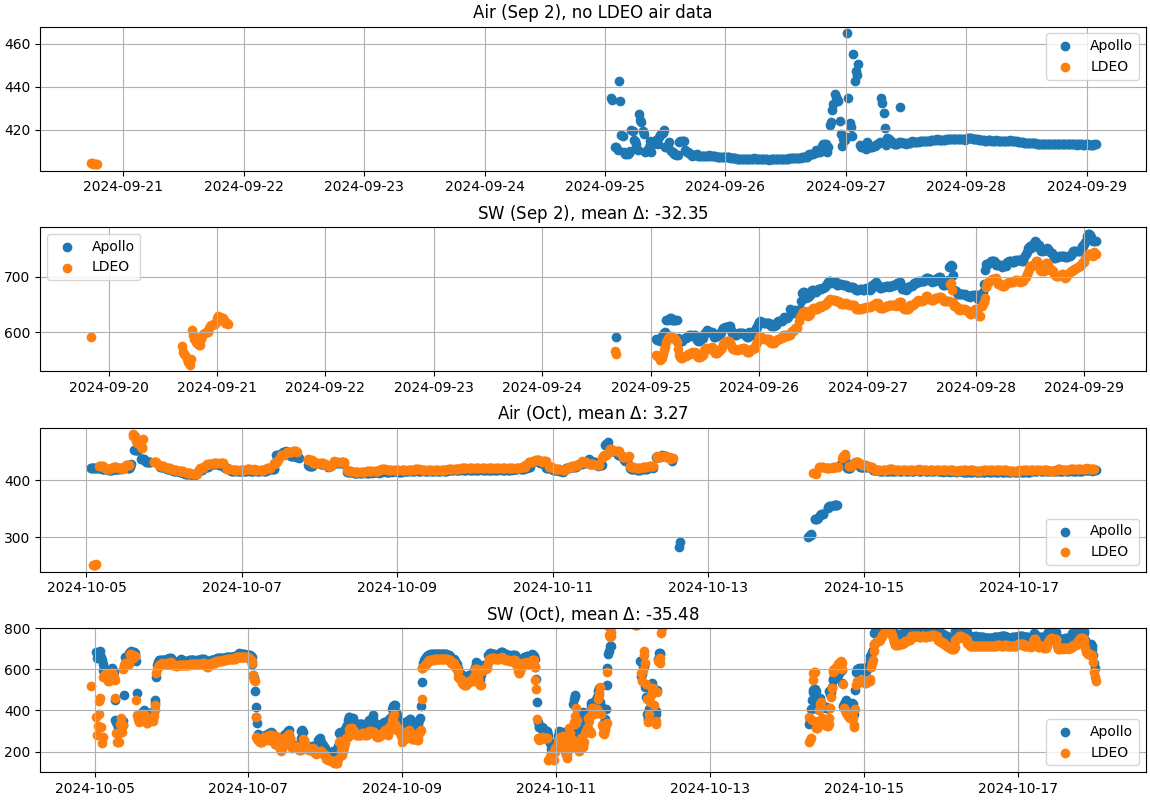

In [87]:
%matplotlib widget

fig, ax = plt.subplots(4,1,figsize = (11.5,8), constrained_layout = True)
ax[0].scatter(apollo_air_aug.time, apollo_air_aug.fco2, label='Apollo')
ax[0].scatter(ldeo_air_aug.time, ldeo_air_aug.fco2, label='LDEO')
ax[0].set_title('Air (Aug), mean $\Delta$: ' + str(delta_air_aug.mean().values.round(2)))
ax[0].grid()
ax[0].legend()

ax[1].scatter(apollo_sea_aug.time, apollo_sea_aug.fco2, label='Apollo')
ax[1].scatter(ldeo_sea_aug.time, ldeo_sea_aug.fco2, label='LDEO')
ax[1].set_title('SW (Aug), mean $\Delta$: ' + str(delta_sea_aug.mean().values.round(2)))
ax[1].grid()
ax[1].legend()

ax[2].scatter(apollo_air_se1.time, apollo_air_se1.fco2, label='Apollo')
ax[2].scatter(ldeo_air_se1.time, ldeo_air_se1.fco2, label='LDEO')
ax[2].set_title('Air (Sep 1), mean $\Delta$ (after 9/6): ' + str(delta_air_se1.mean().values.round(2)))
ax[2].grid()
ax[2].legend()

ax[3].scatter(apollo_sea_se1.time, apollo_sea_se1.fco2, label='Apollo')
ax[3].scatter(ldeo_sea_se1.time, ldeo_sea_se1.fco2, label='LDEO')
ax[3].set_title('SW (Sep 1), mean $\Delta$ (after 9/6): ' + str(delta_sea_se1.mean().values.round(2)))
ax[3].grid()
ax[3].legend()

fig.savefig("C:/Users/annar/OneDrive/Documents/OSU/Research/RCRV/Apollo/ApolloOnTheSKQ/Figures/fco2_aug_sep.jpg", dpi=300)

fig, ax = plt.subplots(4,1,figsize = (11.5,8), constrained_layout = True)
ax[0].scatter(apollo_air_se2.time, apollo_air_se2.fco2, label='Apollo')
ax[0].scatter(ldeo_air_se2.time, ldeo_air_se2.fco2, label='LDEO')
ax[0].set_title('Air (Sep 2), no LDEO air data')
ax[0].grid()
ax[0].legend()

ax[1].scatter(apollo_sea_se2.time, apollo_sea_se2.fco2, label='Apollo')
ax[1].scatter(ldeo_sea_se2.time, ldeo_sea_se2.fco2, label='LDEO')
ax[1].set_title('SW (Sep 2), mean $\Delta$: ' + str(delta_sea_se2.mean().values.round(2)))
ax[1].grid()
ax[1].legend()

ax[2].scatter(apollo_air_oct.time, apollo_air_oct.fco2, label='Apollo')
ax[2].scatter(ldeo_air_oct.time, ldeo_air_oct.fco2, label='LDEO')
ax[2].set_title('Air (Oct), mean $\Delta$: ' + str(delta_air_oct.mean().values.round(2)))
ax[2].grid()
ax[2].legend()

ax[3].scatter(apollo_sea_oct.time, apollo_sea_oct.fco2, label='Apollo')
ax[3].scatter(ldeo_sea_oct.time, ldeo_sea_oct.fco2, label='LDEO')
ax[3].set_title('SW (Oct), mean $\Delta$: ' + str(delta_sea_oct.mean().values.round(2)))
ax[3].grid()
ax[3].set_ylim(100,800)
ax[3].legend()

#fig.savefig("C:/Users/annar/OneDrive/Documents/OSU/Research/RCRV/Apollo/ApolloOnTheSKQ/Figures/fco2_sep_oct.jpg", dpi=300)

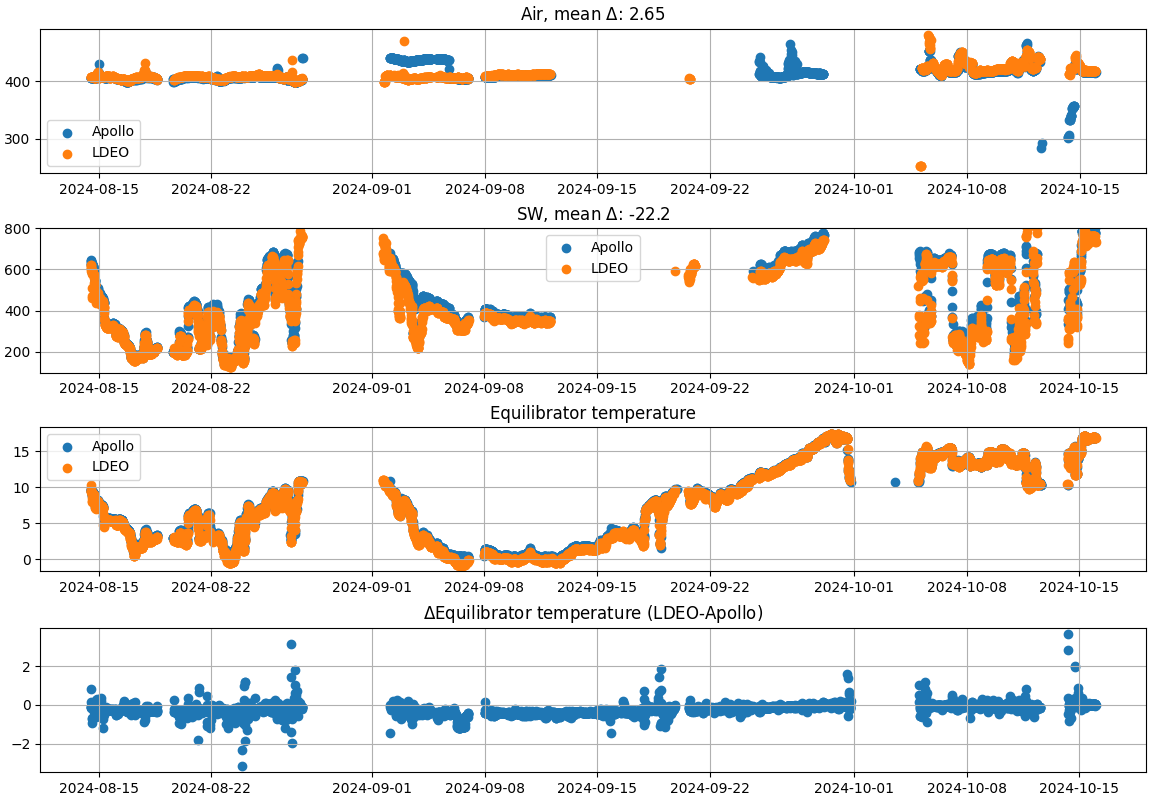

In [64]:
fig, ax = plt.subplots(4,1,figsize = (11.5,8), constrained_layout = True)
ax[0].scatter(apollo_air.time, apollo_air.fco2, label='Apollo')
ax[0].scatter(ldeo_air.time, ldeo_air.fco2, label='LDEO')
ax[0].set_title('Air, mean $\Delta$: ' + str(delta_at.where(delta_at > -10).mean().values.round(2)))
ax[0].grid()
ax[0].legend()

ax[1].scatter(apollo_sea.time, apollo_sea.fco2, label='Apollo')
ax[1].scatter(ldeo_sea.time, ldeo_sea.fco2, label='LDEO')
ax[1].set_title('SW, mean $\Delta$: ' + str(delta_sw.where(delta_sw > -70).mean().values.round(2)))
ax[1].grid()
ax[1].set_ylim(100,800)
ax[1].legend()

ax[2].scatter(apollo_sea.time, apollo_sea.apollo_sbe45_sea_water_temperature, label='Apollo')
ax[2].scatter(ldeo_sea.time, ldeo_sea.equilibrator_temperature_sbe38, label='LDEO')
ax[2].set_title('Equilibrator temperature')
ax[2].grid()
ax[2].legend()

ax[3].scatter(apollo_sea.time, ldeo_sea.equilibrator_temperature_sbe38-apollo_sea.apollo_sbe45_sea_water_temperature)
ax[3].set_title('$\Delta$Equilibrator temperature (LDEO-Apollo)')
ax[3].grid()
fig.savefig("C:/Users/annar/OneDrive/Documents/OSU/Research/RCRV/Apollo/ApolloOnTheSKQ/Figures/fco2_air_sea_teq.jpg", dpi=300)

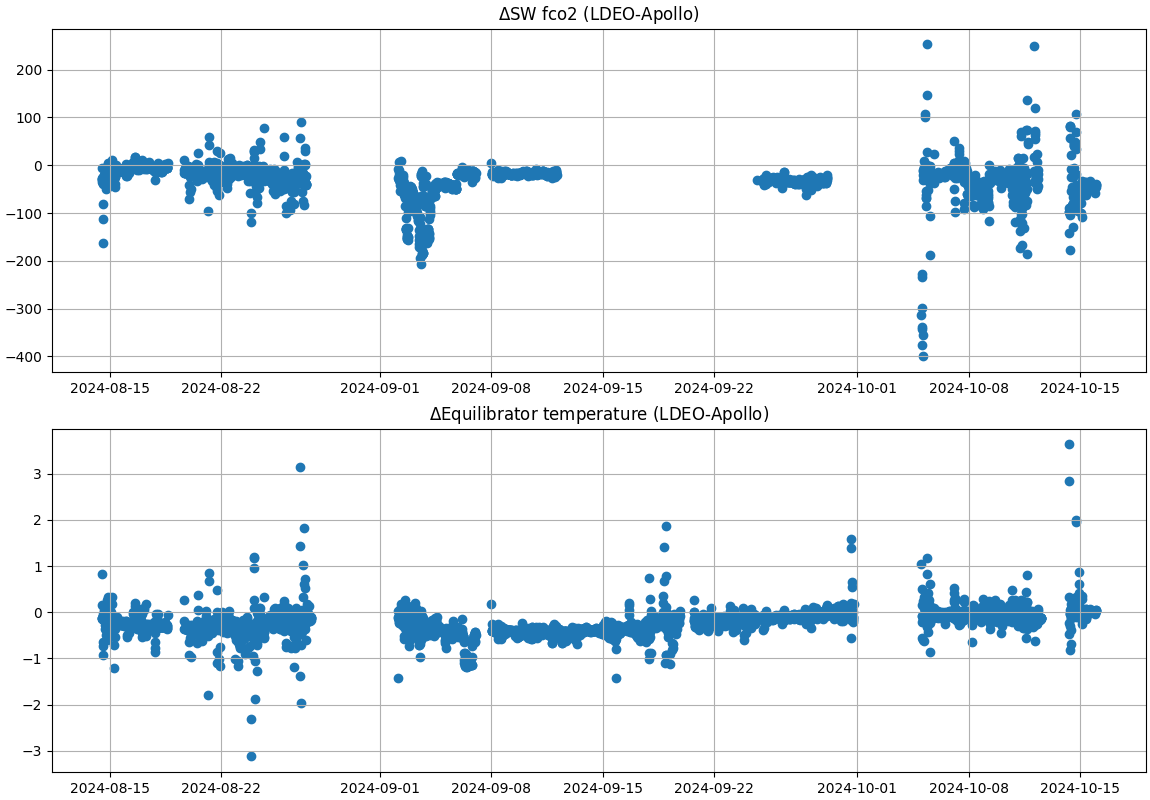

In [65]:
fig, ax = plt.subplots(2,1,figsize = (11.5,8), constrained_layout = True)
ax[0].scatter(apollo_sea.time, ldeo_sea.fco2-apollo_sea.fco2)
ax[0].set_title('$\Delta$SW fco2 (LDEO-Apollo)')
ax[0].grid()

ax[1].scatter(apollo_sea.time, ldeo_sea.equilibrator_temperature_sbe38-apollo_sea.apollo_sbe45_sea_water_temperature)
ax[1].set_title('$\Delta$Equilibrator temperature (LDEO-Apollo)')
ax[1].grid()
fig.savefig("C:/Users/annar/OneDrive/Documents/OSU/Research/RCRV/Apollo/ApolloOnTheSKQ/Figures/fco2_teq.jpg", dpi=300)

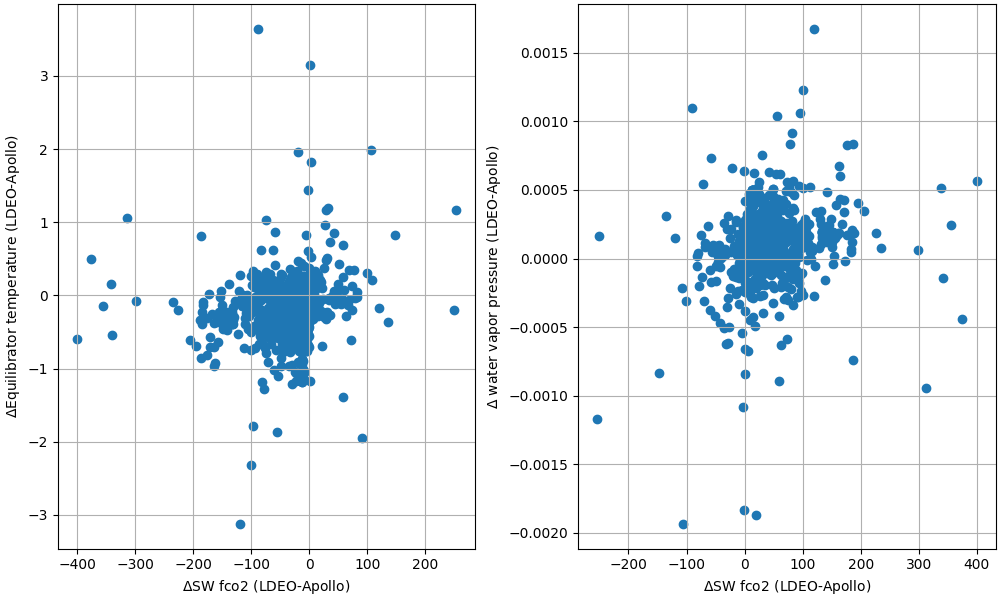

In [79]:
fig, ax = plt.subplots(1,2,figsize = (10,6), constrained_layout = True)
ax[0].scatter(ldeo_sea.fco2-apollo_sea.fco2, ldeo_sea.equilibrator_temperature_sbe38-apollo_sea.apollo_sbe45_sea_water_temperature)
ax[0].set_ylabel('$\Delta$Equilibrator temperature (LDEO-Apollo)')
ax[0].set_xlabel('$\Delta$SW fco2 (LDEO-Apollo)')
ax[0].grid()

ax[1].scatter(apollo_sea.fco2-ldeo_sea.fco2, apollo_sea.water_vapor_pressure-ldeo_sea.water_vapor_pressure)
ax[1].set_ylabel('$\Delta$ water vapor pressure (LDEO-Apollo)')
ax[1].set_xlabel('$\Delta$SW fco2 (LDEO-Apollo)')
ax[1].grid()

fig.savefig("C:/Users/annar/OneDrive/Documents/OSU/Research/RCRV/Apollo/ApolloOnTheSKQ/Figures/fco2_teq_wvp_scatter.jpg", dpi=300)

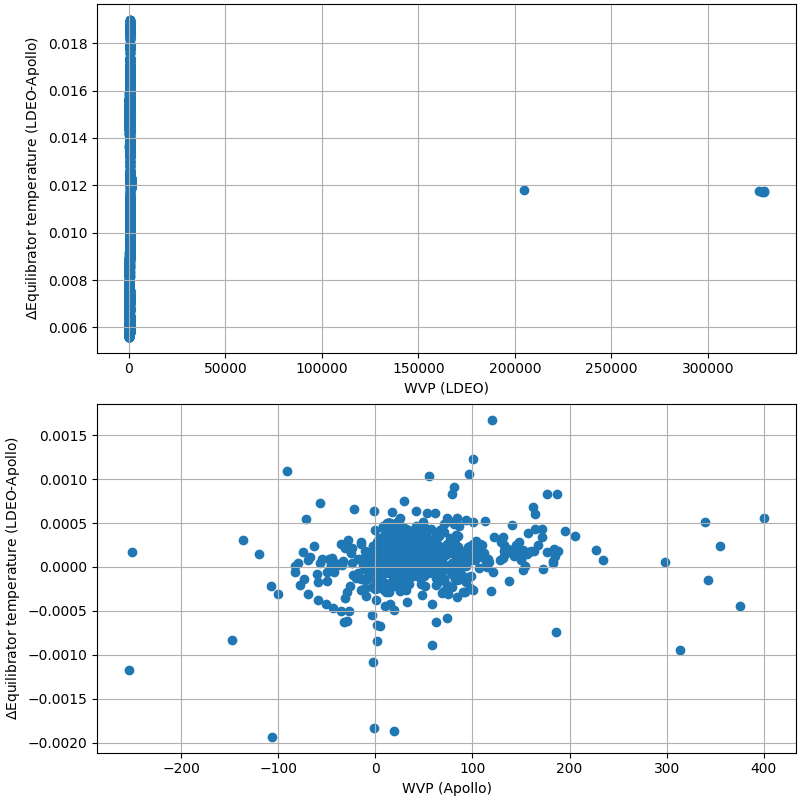

In [76]:
fig, ax = plt.subplots(2,1,figsize = (8,8), constrained_layout = True)
ax[0].scatter(ldeo_sea.fco2, ldeo_sea.water_vapor_pressure)
ax[0].set_ylabel('$\Delta$Equilibrator temperature (LDEO-Apollo)')
ax[0].set_xlabel('WVP (LDEO)')
ax[0].grid()

ax[1].scatter(apollo_sea.fco2-ldeo_sea.fco2, apollo_sea.water_vapor_pressure-ldeo_sea.water_vapor_pressure)
ax[1].set_ylabel('$\Delta$Equilibrator temperature (LDEO-Apollo)')
ax[1].set_xlabel('WVP (Apollo)')
ax[1].grid()

#fig.savefig("C:/Users/annar/OneDrive/Documents/OSU/Research/RCRV/Apollo/ApolloOnTheSKQ/Figures/fco2_wvp.jpg", dpi=300)

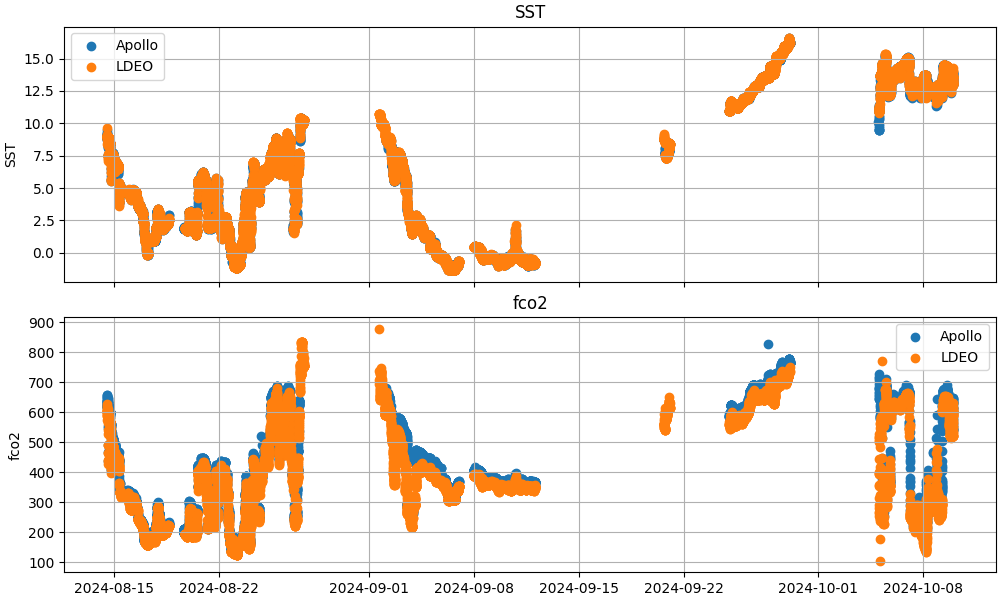

In [100]:
%matplotlib widget

fig,ax = plt.subplots(2,1, figsize = (10,6), sharex = True, constrained_layout = True)
ax[0].scatter(apollo.time.where(apollo.sample_source == 'seawater'),apollo.sea_surface_temperature.where(apollo.sample_source == 'seawater'),label="Apollo")
ax[0].scatter(ldeo.time.where(ldeo.sample_source == 'seawater'),ldeo.sea_surface_temperature.where(ldeo.sample_source == 'seawater'),label="LDEO")
ax[0].set_ylabel('SST')
ax[0].set_title('SST')
ax[0].grid()
ax[0].legend()

ax[1].scatter(apollo.time.where(apollo.sample_source == 'seawater'),apollo.fco2.where(apollo.sample_source == 'seawater'),label="Apollo")
ax[1].scatter(ldeo.time.where(ldeo.sample_source == 'seawater'),ldeo.fco2.where(ldeo.sample_source == 'seawater'),label="LDEO")
ax[1].set_ylabel('fco2')
ax[1].set_title('fco2')
ax[1].grid()
ax[1].legend()